<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install optuna


In [6]:
!pip install category_encoders

In [60]:
import zipfile
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders  import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,root_mean_squared_error


import optuna
import torch
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Lasso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
with zipfile.ZipFile('/content/assessement.zip','r') as zip_ref:
    zip_ref.extractall('/content/data')


# **EDA**

In [9]:
december_chart_inputs_csv = "/content/data/assessement/december-chart-inputs.csv"
december_chart_inputs_df=pd.read_csv(december_chart_inputs_csv)
print(december_chart_inputs_df.shape)
print(december_chart_inputs_df.head(30))

(31, 7)
       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexington  Fort Wayne 

In [10]:
train_test_df=pd.read_csv("/content/data/assessement/train-test.csv")
train_test_df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [11]:
validation_predection_test_csv=pd.read_csv("/content/data/assessement/validation-predictions-template.csv")
validation_predection_test_csv

,load_id,predicted_rate
0,TE-000001,NaN
1,TE-000002,NaN
2,TE-000003,NaN
3,TE-000004,NaN
4,TE-000005,NaN
...,...,...
11995,TE-011996,NaN
11996,TE-011997,NaN
11997,TE-011998,NaN
11998,TE-011999,NaN


In [12]:
validation_csv=pd.read_csv("/content/data/assessement/validation.csv")
validation_csv

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,TE-011996,Fort Wayne,Louisville,41.31561,-85.36206,37.36588,-87.47153,377.4,Dry Van,38638.0,2025-12-31,1.03391,2.15984
11996,TE-011997,Oklahoma City,Memphis,31.88294,-98.58097,35.56802,-89.52871,707.4,Dry Van,27685.0,2025-12-31,0.99846,2.46279
11997,TE-011998,Nashville,Montgomery,35.29479,-88.08915,31.37602,-86.10743,359.4,Flatbed,35522.0,2025-12-31,0.98564,2.09568
11998,TE-011999,Syracuse,San Antonio,42.80915,-76.89973,29.50969,-98.40059,1750.8,Dry Van,31755.0,2025-12-31,1.03100,1.95125


In [13]:
train_test_df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [14]:
train_test_df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [15]:
# checking the null values in train_test-df
train_test_df.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [16]:
null_value_percentage=(train_test_df.isnull().sum()/len(train_test_df))*100
null_value_percentage

,0
load_id,0.000000
pickup,0.000000
delivery,0.000000
pickup_lat,0.000000
pickup_lon,0.000000
delivery_lat,0.000000
delivery_lon,0.000000
distance,0.000000
equipment,0.000000
weight,0.625000


In [17]:
# since the percentage of missign values is smaller than 5% ,dropping the value is considered safest method.so we drop the null values
train_test_df.dropna(inplace=True)

# Negative weights — physically impossible
neg_weight = train_test_df[train_test_df.weight < 0]
print(len(neg_weight), "rows with negative weight")


289 rows with negative weight


In [18]:
target_col=train_test_df['posted_rate']


In [19]:
df=train_test_df
y=target_col
df.head()



,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


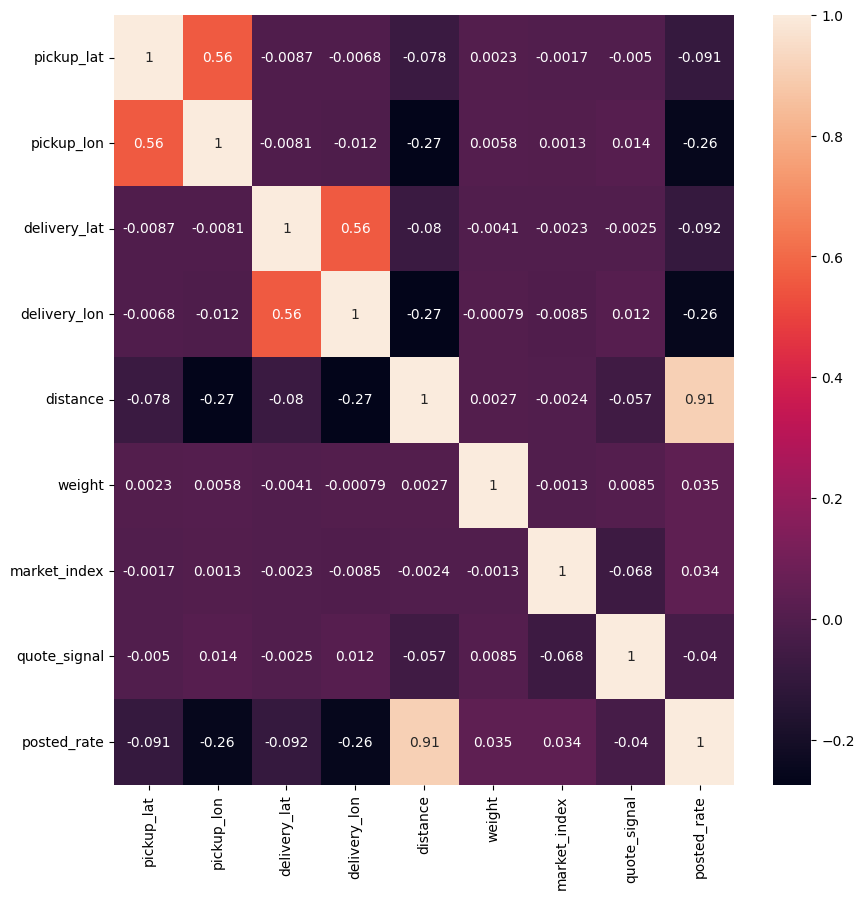

In [20]:
# correlation between numerical cols
# plotting the heatmap for correlation
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [21]:
#numerical_cols
num_cols=df.select_dtypes(include=['int64','float64']).columns
# categorical_cols
cat_cols=df.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'posted_rate'],
      dtype='object')
Index(['load_id', 'pickup', 'delivery', 'equipment', 'date'], dtype='object')


In [22]:
print(y.mean(), y.median())

2373.9594489403507 2030.18


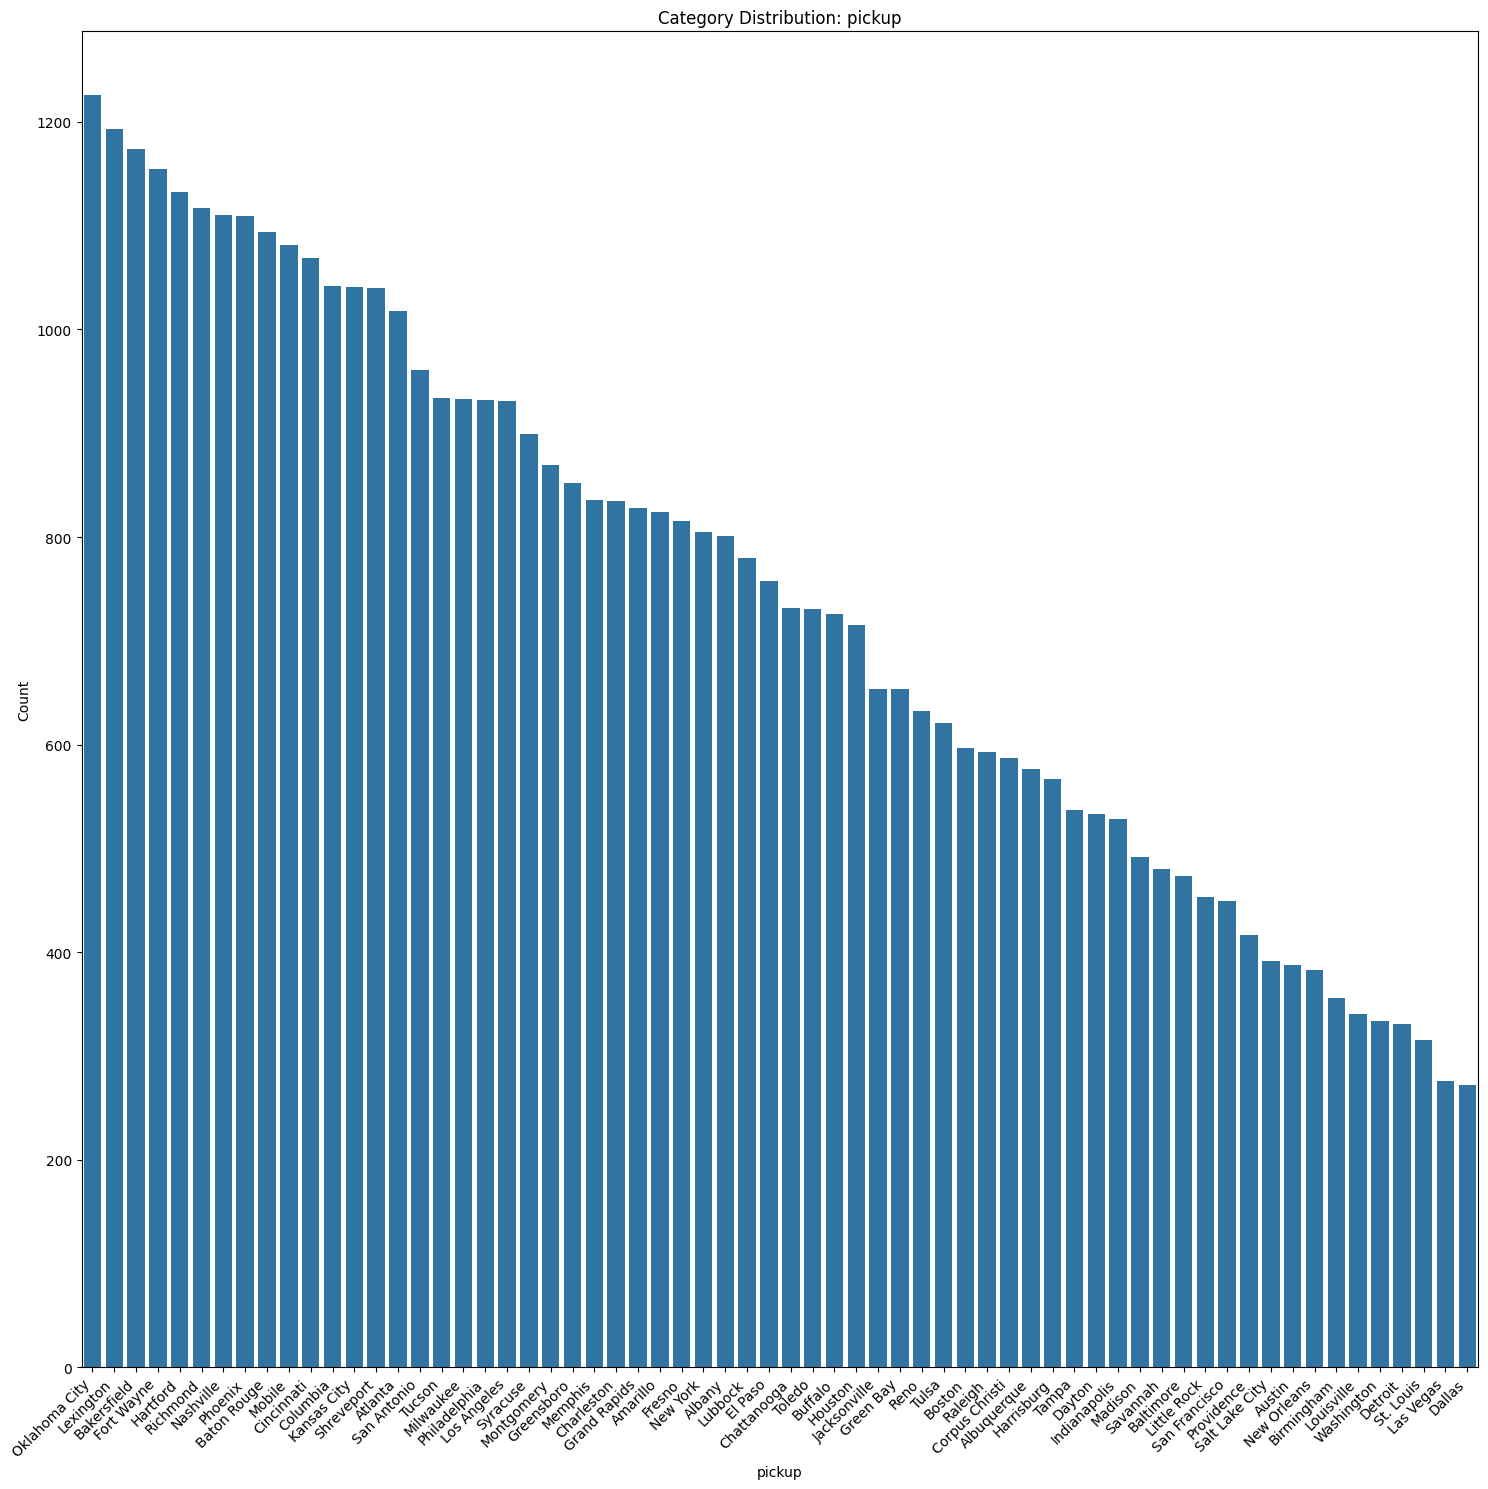

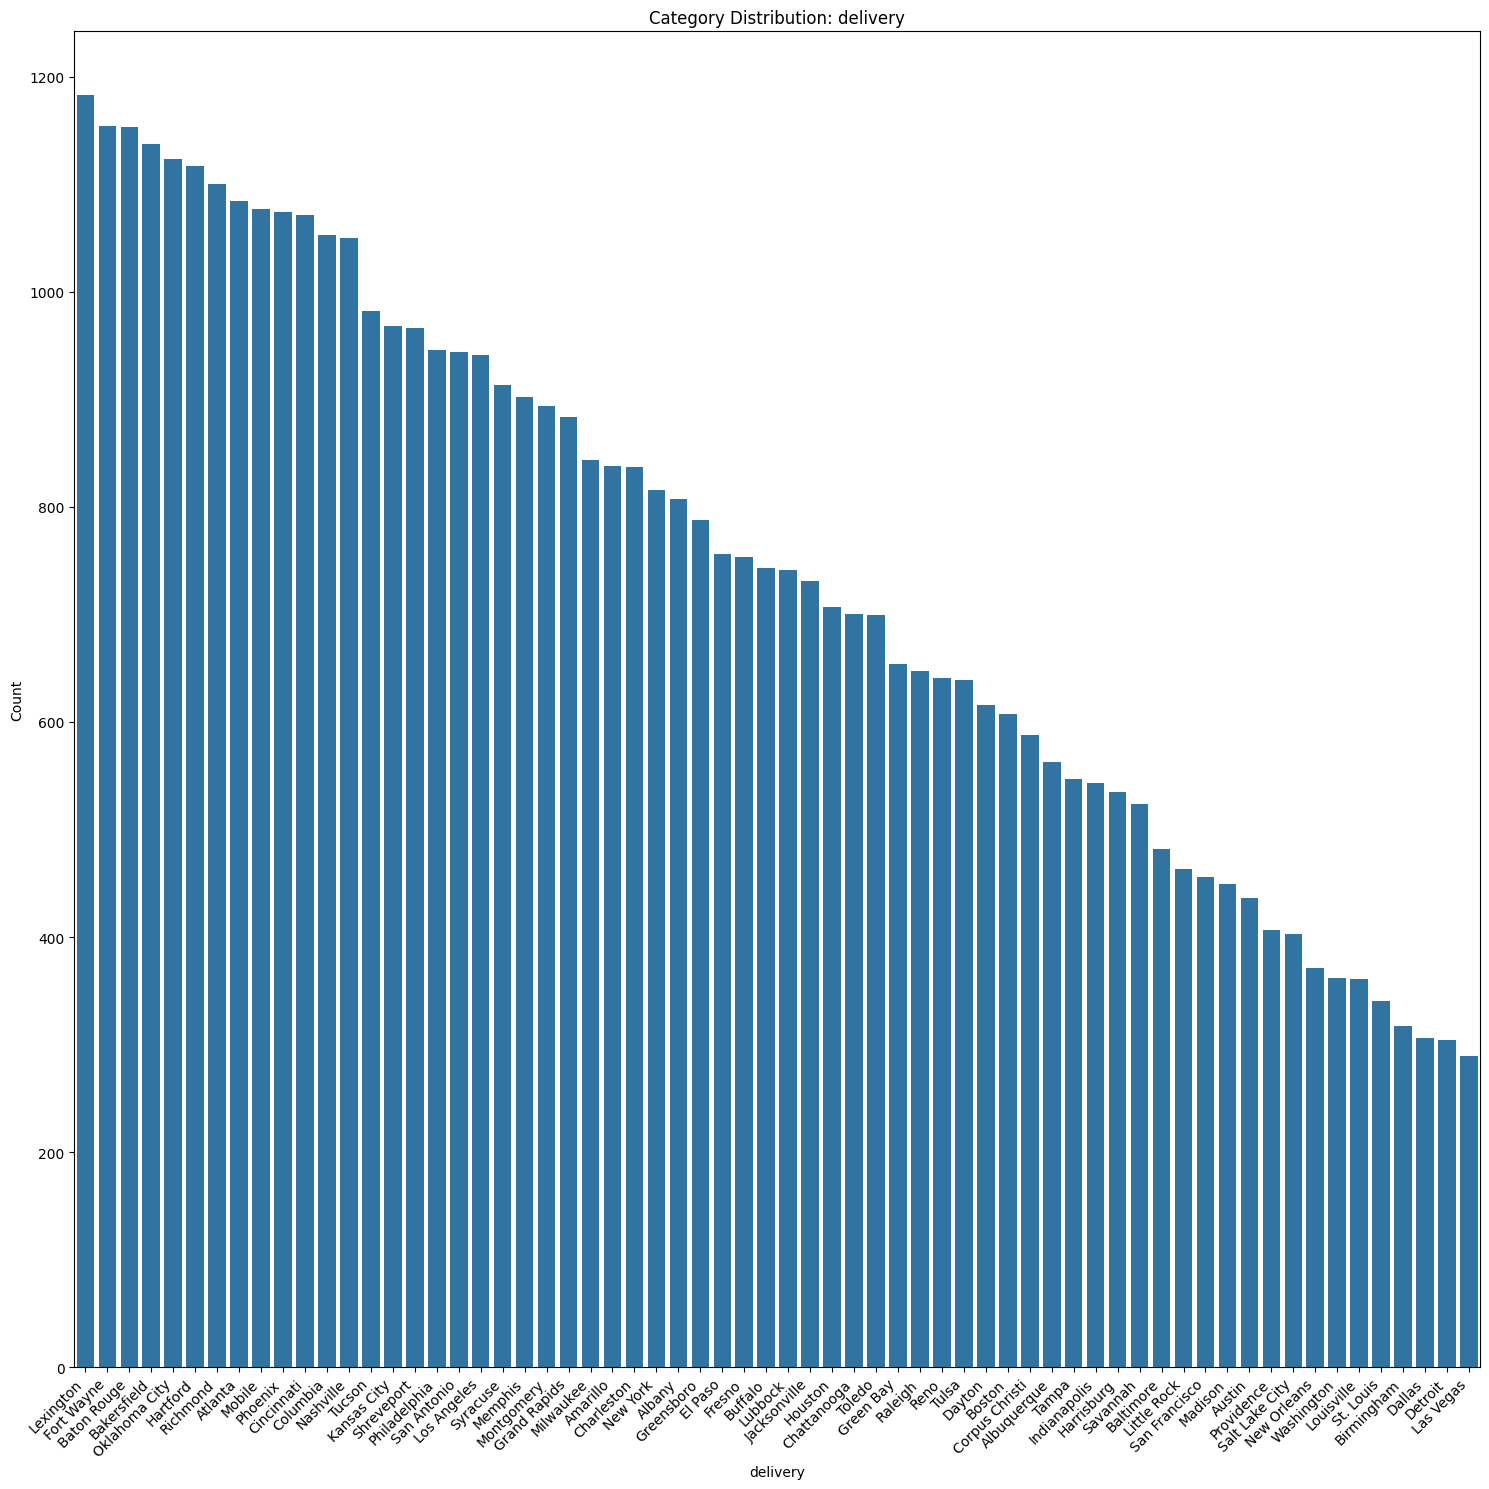

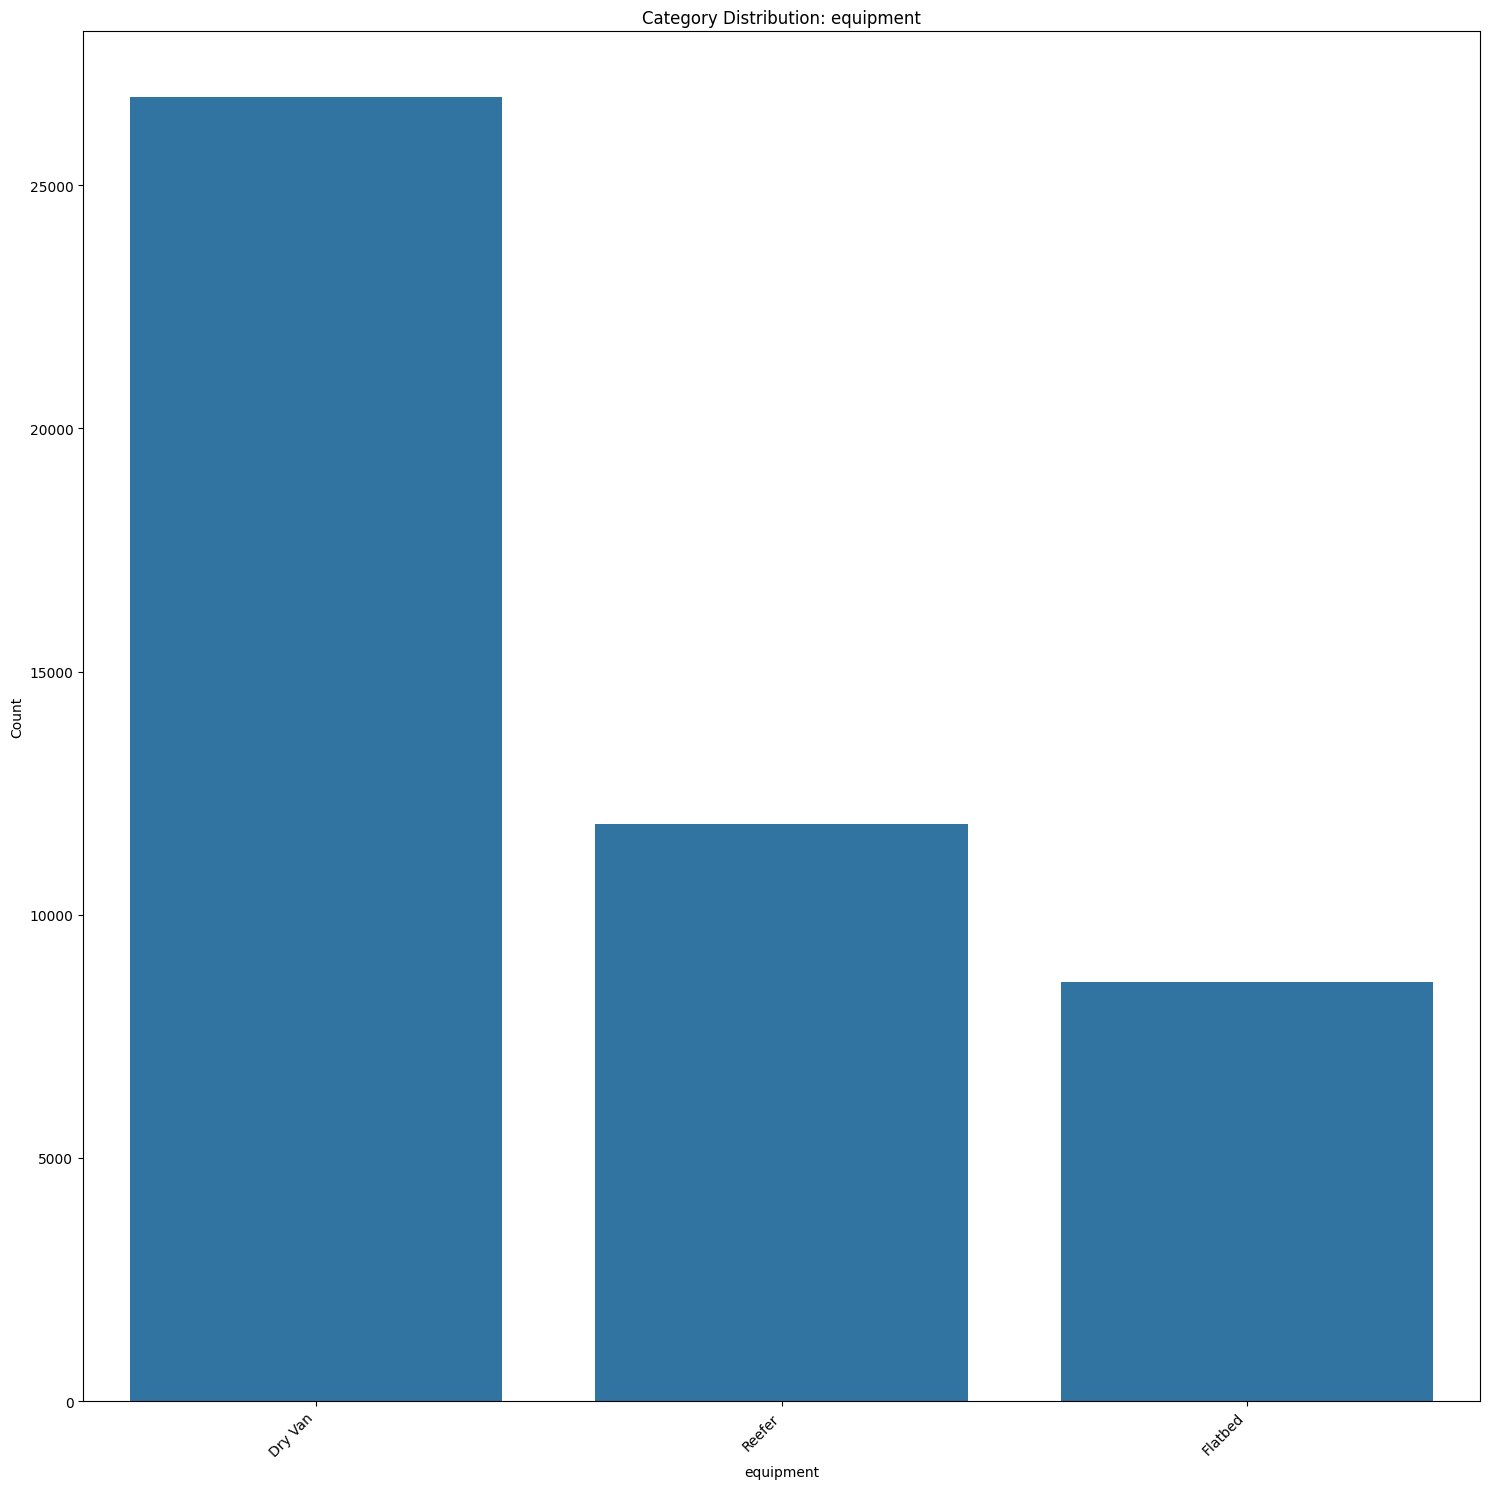

In [23]:
# plotting the count plot for categorical
categorical_dataset_plot=['pickup', 'delivery', 'equipment',]
for col in categorical_dataset_plot:
  plt.figure(figsize=(15,15))
  sns.countplot(x=col,data=df,order=df[col].value_counts().index)
  plt.title(f'Category Distribution: {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()



# **Preprocess the data**

In [24]:
# droping the null values
df.dropna(inplace=True)

# replacing the -ve weight with mean weight
df.loc[df['weight'] < 0, 'weight'] =df['weight'].mean()


In [25]:
# Separate features and target
X = df.drop(columns=['load_id', 'posted_rate'])
y = y

# Parse date signals
X['date'] = pd.to_datetime(X['date'])
X['pickup_month'] = X['date'].dt.month
X['pickup_day_of_week'] = X['date'].dt.dayofweek
X = X.drop(columns=['date'])

In [26]:
def calculate_haversine(df):
    lat1, lon1 = np.radians(df['pickup_lat']), np.radians(df['pickup_lon'])
    lat2, lon2 = np.radians(df['delivery_lat']), np.radians(df['delivery_lon'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    df['haversine_distance'] = 3956 * c
    return df

X = calculate_haversine(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# **Feature Enginnering**

In [29]:
avg_dist_map = X_train.groupby('equipment')['distance'].mean()
avg_weight_map = X_train.groupby('equipment')['weight'].mean()

for split in [X_train, X_test]:
    split['avg_dist_by_equip'] = split['equipment'].map(avg_dist_map)
    split['avg_weight_by_equip'] = split['equipment'].map(avg_weight_map)
    split['dist_deviation'] = split['distance'] - split['avg_dist_by_equip']
    split['weight_deviation'] = split['weight'] - split['avg_weight_by_equip']
    split['mile_per_index'] = split['distance'] / split['market_index']
    split['mile_per_weight'] = split['distance'] / split['weight']

In [30]:
# # new features add
# # Helps the model understand if market tightness impacts long-haul routes differently than short-haul regional runs.
# df['mile_per_index']=df['distance']/ df['market_index']

# #  Heavy loads traveling short distances have vastly different pricing structures than light loads traveling long distances
# df['mile_per_weight']=df['distance']/df['weight']



In [31]:
# #  calculate the overall average distance and weight for every truck type.
# # This tells the model what is "normal" for a Flatbed vs. a Reefer (refrigerated truck) vs. a Dry Van.
# # benchmark
# df['avg_dist_by_equip'] = df.groupby('equipment')['distance'].transform('mean')
# df['avg_weight_by_equip'] = df.groupby('equipment')['weight'].transform('mean')

# # calculate how much  specific load deviates from the truck's normal behavior
# df['dist_deviation'] = df['distance'] - df['avg_dist_by_equip']
# df['weight_deviation'] = df['weight'] - df['avg_weight_by_equip']

In [32]:
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [33]:
numeric_features = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
                     'distance', 'haversine_distance', 'weight', 'market_index',
                     'quote_signal', 'pickup_month', 'pickup_day_of_week',
                     'avg_dist_by_equip', 'avg_weight_by_equip',
                     'dist_deviation', 'weight_deviation',
                     'mile_per_index', 'mile_per_weight']

low_cardinality_cat = ['equipment']
high_cardinality_cat = ['pickup', 'delivery']

pipeline

In [34]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

low_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('target_enc', TargetEncoder(smoothing=10.0))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('low_cat', low_cat_transformer, low_cardinality_cat),
        ('high_cat', high_cat_transformer, high_cardinality_cat)
    ]
)

# **Modeling**

In [35]:
def objective(trial, X, y, preprocessor):
    model_type = trial.suggest_categorical("model_type", ["xgboost", "randomforest"])

    if model_type == "randomforest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("rf_max_depth", 4, 12),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
            random_state=42,
            n_jobs=-1
        )
    elif model_type == "xgboost":
        model = xgb.XGBRegressor(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 8),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.1, log=True),
            subsample=trial.suggest_float("xgb_subsample", 0.6, 1.0),
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            device="cuda",
            tree_method="hist",
            n_jobs=-1
        )
    else:
        raise ValueError("Invalid model type")

    pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", model)])
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_jobs = 1 if model_type == "xgboost" else -1

    try:
        scores = cross_val_score(
            pipeline, X, y, cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=cv_jobs,
            error_score="raise"
        )
        rmse = -scores.mean()
        return rmse
    except Exception as e:
        print(f"Trial {trial.number} failed due to error:\n{e}")
        return float("inf")

In [36]:
# create study
study = optuna.create_study(
    direction="minimize",
)
study.optimize(
    lambda trial: objective(trial, X_train, y_train, preprocessor),
    n_trials=50,
    n_jobs=1,
)
print(f"Optimization complete. Best MSE: {study.best_value:.4f}")

[I 2026-09-11 13:28:02,325] A new study created in memory with name: no-name-c7de4bb6-35e9-4ced-a6e7-32c63bdf1563
[I 2026-09-11 13:28:10,379] Trial 0 finished with value: 593.2012343428065 and parameters: {'model_type': 'xgboost', 'xgb_n_estimators': 350, 'xgb_max_depth': 5, 'xgb_lr': 0.017950926763753157, 'xgb_subsample': 0.7793072099439615}. Best is trial 0 with value: 593.2012343428065.
[I 2026-09-11 13:28:16,200] Trial 1 finished with value: 593.310957238841 and parameters: {'model_type': 'xgboost', 'xgb_n_estimators': 150, 'xgb_max_depth': 5, 'xgb_lr': 0.037912588061681594, 'xgb_subsample': 0.7284502117216722}. Best is trial 0 with value: 593.2012343428065.
[I 2026-09-11 13:31:30,247] Trial 2 finished with value: 605.7664497220081 and parameters: {'model_type': 'randomforest', 'rf_n_estimators': 250, 'rf_max_depth': 6, 'rf_min_samples_split': 9}. Best is trial 0 with value: 593.2012343428065.
[I 2026-09-11 13:31:41,803] Trial 3 finished with value: 605.5396708581966 and parameters

Optimization complete. Best MSE: 590.8074


In [37]:
nrmse = study.best_value / y.mean()  # or / (y.max() - y.min())
print(nrmse)

0.2488700485499131


# **Evaluation**

In [38]:
best_params = study.best_params
model_type = best_params["model_type"]

if model_type == "randomforest":
    best_model = RandomForestRegressor(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        random_state=42, n_jobs=-1
    )
elif model_type == "xgboost":
    best_model = xgb.XGBRegressor(
        n_estimators=best_params["xgb_n_estimators"],
        max_depth=best_params["xgb_max_depth"],
        learning_rate=best_params["xgb_lr"],
        subsample=best_params["xgb_subsample"],
        objective="reg:squarederror", eval_metric="rmse",
        random_state=42, device="cuda", tree_method="hist", n_jobs=-1
    )
else:  # Lasso
    best_model = Lasso(alpha=best_params["lasso_alpha"], max_iter=10000, random_state=42)

best_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", best_model)])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
final_rmse = root_mean_squared_error(y_test, y_pred)
final_nrmse = final_rmse / y_test.mean()

print(f"Final Test RMSE: {final_rmse:.4f}")
print(f"Final Test NRMSE: {final_nrmse:.4f}")


Final Test RMSE: 606.9398
Final Test NRMSE: 0.2578


# final Production model

In [41]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full_log = pd.concat([y_train_log, y_test_log], axis=0)

final_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", best_model)])
final_pipeline.fit(X_full, y_full_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pickup_lat', 'pickup_lon',
                                                   'delivery_lat',
                                                   'delivery_lon', 'distance',
                                                   'haversine_distance',
                                                   'weight', 'market_index',
                                                   'quote_signal',
                                                   'pickup_month',
                                                   'pickup_day_of_week',
                                                   'avg_dist_by_equip',
                                                   'avg...
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.024025469335164244, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [45]:
val_df = pd.read_csv('/content/data/assessement/validation.csv')
val_load_ids = val_df['load_id'].copy()
X_val = val_df.drop(columns=['load_id'])

X_val['date'] = pd.to_datetime(X_val['date'])
X_val['pickup_month'] = X_val['date'].dt.month
X_val['pickup_day_of_week'] = X_val['date'].dt.dayofweek
X_val = X_val.drop(columns=['date'])

X_val = calculate_haversine(X_val)

X_val['avg_dist_by_equip'] = X_val['equipment'].map(avg_dist_map)
X_val['avg_weight_by_equip'] = X_val['equipment'].map(avg_weight_map)
X_val['dist_deviation'] = X_val['distance'] - X_val['avg_dist_by_equip']
X_val['weight_deviation'] = X_val['weight'] - X_val['avg_weight_by_equip']
X_val['mile_per_index'] = X_val['distance'] / X_val['market_index']
X_val['mile_per_weight'] = X_val['distance'] / X_val['weight']

val_pred = np.expm1(final_pipeline.predict(X_val))

template = pd.read_csv('/content/data/assessement/validation-predictions-template.csv')
pred_map = dict(zip(val_load_ids, val_pred))
template['predicted_rate'] = template['load_id'].map(pred_map)

assert template['predicted_rate'].isna().sum() == 0, "Missing predictions!"
template.to_csv('validation_predictions.csv', index=False)

In [46]:
# Predict december-chart-inputs.csv
dec_df = pd.read_csv('/content/data/assessement/december-chart-inputs.csv')

X_dec = dec_df.drop(columns=['predicted_rate'])

X_dec['date'] = pd.to_datetime(X_dec['date'])
X_dec['pickup_month'] = X_dec['date'].dt.month
X_dec['pickup_day_of_week'] = X_dec['date'].dt.dayofweek
X_dec = X_dec.drop(columns=['date'])

# Columns this file doesn't have at all — add as NaN so the imputer fills them
for col in ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
            'market_index', 'quote_signal']:
    X_dec[col] = np.nan

X_dec['haversine_distance'] = np.nan  # can't compute without lat/lon

# Groupby features — these CAN be computed (equipment, distance, weight all present)
X_dec['avg_dist_by_equip'] = X_dec['equipment'].map(avg_dist_map)
X_dec['avg_weight_by_equip'] = X_dec['equipment'].map(avg_weight_map)
X_dec['dist_deviation'] = X_dec['distance'] - X_dec['avg_dist_by_equip']
X_dec['weight_deviation'] = X_dec['weight'] - X_dec['avg_weight_by_equip']
X_dec['mile_per_index'] = np.nan  # needs market_index, which is missing
X_dec['mile_per_weight'] = X_dec['distance'] / X_dec['weight']

dec_pred = np.expm1(final_pipeline.predict(X_dec))
dec_df['predicted_rate'] = dec_pred
dec_df.to_csv('december-chart-inputs.csv', index=False)

In [61]:
print(np.__version__)
print(pd.__version__)
print(mp.__version__)

2.1.3
2.2.3
3.10.0


In [110]:
dci=pd.read_csv("/content/validation_predictions.csv")
dci

,load_id,predicted_rate
0,TE-000001,844.38635
1,TE-000002,5024.11430
2,TE-000003,5298.47560
3,TE-000004,4046.13770
4,TE-000005,1811.14390
...,...,...
11995,TE-011996,858.42960
11996,TE-011997,1564.68330
11997,TE-011998,940.60930
11998,TE-011999,3380.10380


In [119]:
!python script.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv --output-dir scorer_results

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
